### Importing of libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
import sqlite3
%matplotlib inline
import math
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1_l2
import warnings
warnings.filterwarnings('ignore')

### Data Import

In [2]:
db_path = r"E:\Machine Learning Research\DataModelling\IDA_Data.db"  # <-- change this to your actual .db file path
table_name = "IDA_Data"                    # <-- your table name

conn = sqlite3.connect(db_path)
df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
conn.close()

# === Display===
# print(df.shape)
# print(list(df.columns))
# === Optionally, show first few rows ===
# print(InputHeads)
# print(OutputHeads)
# print("\nFirst 5 rows:")
# print(df.columns)
# df.columns

AllColumns = ['id', 'Earthquake', 'ScaleFactor', 'Building', 'BaseCondition', 'ly-Ly', 'lx-Lx', 'ly-Ly-lx-Lx', 'ly-lx-', 'lx-ly-', 'lx-ly--ly-lx-', 'Plan-area', 'Seismic-weight', 
              'StiffnessX_Story5', 'StiffnessX_Story4', 'StiffnessX_Story3', 'StiffnessX_Story2', 'StiffnessX_Story1', 'StiffnessX_Total', 'Layer1_FrictionA', 'Layer1_G_kPa', 
              'Layer1_E_kPa', 'Layer1_B_kPa', 'Layer1_SpGr', 'Layer1_Cohesion', 'Layer2_FrictionA', 'Layer2_G_kPa', 'Layer2_E_kPa', 'Layer2_B_kPa', 'Layer2_SpGr', 'Layer2_Cohesion',
              'Layer3_FrictionA', 'Layer3_G_kPa', 'Layer3_E_kPa', 'Layer3_B_kPa', 'Layer3_SpGr', 'Layer3_Cohesion', 'PGA', 'Magnitude', 'Mechanism', 'Rjb', 'Rrup', 'Vs30', 'cav_gs', 
              'scav_gs', 'bcav_gs', 'arias_mps', 'husid_s', 'spi_mps', 'hous_m', 'maxacceleration_mps2', 'maxvelocity_mps', 'maxdisplacement_m', 'maxpsd_cmps', 'maxsa_mps2', 'maxpsv_mps', 
              'Fundamental_Period', 'Drift-X_Level-1', 'Drift-X_Level-2', 'Drift-X_Level-3', 'Drift-X_Level-4', 'Drift-X_Level-5', 'Drift-X_Level-6', 'Drift-Y_Level-1', 'Drift-Y_Level-2',
              'Drift-Y_Level-3', 'Drift-Y_Level-4', 'Drift-Y_Level-5', 'Drift-Y_Level-6', 'Displacement-X_Level-1', 'Displacement-X_Level-2', 'Displacement-X_Level-3', 'Displacement-X_Level-4',
              'Displacement-X_Level-5', 'Displacement-X_Level-6', 'Displacement-Y_Level-1', 'Displacement-Y_Level-2', 'Displacement-Y_Level-3', 'Displacement-Y_Level-4', 'Displacement-Y_Level-5',
              'Displacement-Y_Level-6', 'Reaction-Force-X_Level-1', 'Reaction-Force-X_Level-2', 'Reaction-Force-X_Level-3', 'Reaction-Force-X_Level-4', 'Reaction-Force-X_Level-5', 'Reaction-Force-X_Level-6', 
              'Reaction-Force-Y_Level-1', 'Reaction-Force-Y_Level-2', 'Reaction-Force-Y_Level-3', 'Reaction-Force-Y_Level-4', 'Reaction-Force-Y_Level-5', 'Reaction-Force-Y_Level-6', 'Reaction-Moment-X_Level-1',
              'Reaction-Moment-X_Level-2', 'Reaction-Moment-X_Level-3', 'Reaction-Moment-X_Level-4', 'Reaction-Moment-X_Level-5', 'Reaction-Moment-X_Level-6', 'Reaction-Moment-Y_Level-1',
              'Reaction-Moment-Y_Level-2', 'Reaction-Moment-Y_Level-3', 'Reaction-Moment-Y_Level-4', 'Reaction-Moment-Y_Level-5', 'Reaction-Moment-Y_Level-6', 'Rotation-X_Level-1', 'Rotation-X_Level-2',
              'Rotation-X_Level-3', 'Rotation-X_Level-4', 'Rotation-X_Level-5', 'Rotation-X_Level-6', 'Rotation-Y_Level-1', 'Rotation-Y_Level-2', 'Rotation-Y_Level-3', 'Rotation-Y_Level-4', 'Rotation-Y_Level-5',
              'Rotation-Y_Level-6', 'Rotation-Z_Level-1', 'Rotation-Z_Level-2', 'Rotation-Z_Level-3', 'Rotation-Z_Level-4', 'Rotation-Z_Level-5', 'Rotation-Z_Level-6', 'Torsional-Irregularity-Ratio_Level-1',
              'Torsional-Irregularity-Ratio_Level-2', 'Torsional-Irregularity-Ratio_Level-3', 'Torsional-Irregularity-Ratio_Level-4', 'Torsional-Irregularity-Ratio_Level-5', 'Torsional-Irregularity-Ratio_Level-6',
              'Max-Uplift_Level-1', 'Max-Uplift-Point_Level-1', 'Max-Settlement_Level-1', 'Max-Settlement-Point_Level-1', 'Max-Pseudo-Time_Level-1']

### Data Processing

In [3]:
def dataPreparation(DoNormalize = True,Z_ScoreScaler = True    ,        ModelSet = 2     ,includeCategoricalData = False  ):
    
    # Creating of the PeakGroundAcceleration column on the database by product of ScaleFactor and MaximumAcceleration of the data
    df['maxacceleration_mps2'] = pd.to_numeric(df['maxacceleration_mps2'], errors='coerce')
    df['ScaleFactor'] = pd.to_numeric(df['ScaleFactor'], errors='coerce')
    df['PeakGroundAcceleration'] = df['maxacceleration_mps2'] * df['ScaleFactor']
    
    #Creating of the Prediction column as Max drift of the all levels merger in single column as below
    drift_cols = [    'Drift-X_Level-1', 'Drift-X_Level-2', 'Drift-X_Level-3',    'Drift-X_Level-4', 'Drift-X_Level-5', 'Drift-X_Level-6']
    df[drift_cols] = df[drift_cols].apply(pd.to_numeric, errors='coerce')
    df['Max_Drift_X'] = df[drift_cols].max(axis=1)
    
    # Check for any NaNs that might have appeared due to conversion issues
    # print(df[['maxacceleration_mps2', 'ScaleFactor', 'PeakGroundAcceleration']].sample(50))
    # print("Number of NaNs in new column:", df['PeakGroundAcceleration'].isna().sum())
    
    InputHeadsAvailableAll = ['Earthquake', 'ScaleFactor', 'Building', 'BaseCondition', 'ly-Ly', 'lx-Lx', 'ly-Ly-lx-Lx', 'ly-lx-', 'lx-ly-', 'lx-ly--ly-lx-', 'Plan-area', 'Seismic-weight', 
                  'StiffnessX_Story5', 'StiffnessX_Story4', 'StiffnessX_Story3', 'StiffnessX_Story2', 'StiffnessX_Story1', 'StiffnessX_Total', 
                  'Layer1_FrictionA', 'Layer1_G_kPa', 'Layer1_E_kPa', 'Layer1_B_kPa', 'Layer1_SpGr', 'Layer1_Cohesion',
                  'Layer2_FrictionA', 'Layer2_G_kPa', 'Layer2_E_kPa', 'Layer2_B_kPa', 'Layer2_SpGr', 'Layer2_Cohesion', 
                  'Layer3_FrictionA', 'Layer3_G_kPa', 'Layer3_E_kPa', 'Layer3_B_kPa', 'Layer3_SpGr', 'Layer3_Cohesion', 
                  'PGA', 'Magnitude', 'Mechanism', 'Rjb', 'Rrup', 'Vs30', 'cav_gs', 'scav_gs', 'bcav_gs', 'arias_mps', 'husid_s', 'spi_mps', 'hous_m', 'maxacceleration_mps2',
                  'maxvelocity_mps', 'maxdisplacement_m', 'maxpsd_cmps', 'maxsa_mps2', 'maxpsv_mps', 
                  'Fundamental_Period']
    InputHeadsSelected = ['ly-Ly', 'lx-Lx', 'ly-Ly-lx-Lx', 'ly-lx-', 'lx-ly-', 'lx-ly--ly-lx-',
                   'StiffnessX_Total', 'Plan-area', 'Seismic-weight', 
                  'Layer1_FrictionA', 'Layer1_G_kPa', 'Layer1_E_kPa', 'Layer1_B_kPa', 'Layer1_SpGr', 'Layer1_Cohesion',
                  'Layer2_FrictionA', 'Layer2_G_kPa', 'Layer2_E_kPa', 'Layer2_B_kPa', 'Layer2_SpGr', 'Layer2_Cohesion', 
                  'Layer3_FrictionA', 'Layer3_G_kPa', 'Layer3_E_kPa', 'Layer3_B_kPa', 'Layer3_SpGr', 'Layer3_Cohesion', 
                          
                  "PeakGroundAcceleration", 'Magnitude', 'arias_mps','maxpsd_cmps', 'maxsa_mps2', 'maxpsv_mps',  'cav_gs', 
                             'Fundamental_Period']
    # InputHeadsSelected = InputHeadsAvailableAll

    
    #Best performer for the fixedbase and displacement output
                   # "PeakGroundAcceleration", 'Magnitude', 'arias_mps','maxpsd_cmps', 'maxsa_mps2', 'maxpsv_mps',  'cav_gs', 
                   #           'Fundamental_Period']
    #Best performer for the maximum drift along X with r2 as 89.36 (Donot include  'Plan-area', 'Seismic-weight', 'StiffnessX_Total', as they donot produce any effect and only add burden to model)
    # InputHeadsSelected = ['ly-Ly', 'lx-Lx', 'ly-Ly-lx-Lx', 'ly-lx-', 'lx-ly-', 'lx-ly--ly-lx-',
                   
    #               'Layer1_FrictionA', 'Layer1_G_kPa', 'Layer1_E_kPa', 'Layer1_B_kPa', 'Layer1_SpGr', 'Layer1_Cohesion',
    #               'Layer2_FrictionA', 'Layer2_G_kPa', 'Layer2_E_kPa', 'Layer2_B_kPa', 'Layer2_SpGr', 'Layer2_Cohesion', 
    #               'Layer3_FrictionA', 'Layer3_G_kPa', 'Layer3_E_kPa', 'Layer3_B_kPa', 'Layer3_SpGr', 'Layer3_Cohesion', 
                          
    #               "PeakGroundAcceleration", 'Magnitude', 'arias_mps','maxpsd_cmps', 'maxsa_mps2', 'maxpsv_mps',  'cav_gs', 
    #                          'Fundamental_Period']
    #Best performer for the fixed and output as Reaction-Force-X_Level-1:  r2 as 0.95 max with 15 features
    # InputHeadsSelected = ['Earthquake', 'Building', 'Fundamental_Period',  'ly-Ly', 'lx-Lx', 'ly-Ly-lx-Lx',
    #               'Layer1_FrictionA', 'Layer1_G_kPa', 'Layer1_E_kPa', 'Layer1_B_kPa', 'Layer1_SpGr', 'Layer1_Cohesion',
    #               'Layer2_FrictionA', 'Layer2_G_kPa', 'Layer2_E_kPa', 'Layer2_B_kPa', 'Layer2_SpGr', 'Layer2_Cohesion', 
    #               'Layer3_FrictionA', 'Layer3_G_kPa', 'Layer3_E_kPa', 'Layer3_B_kPa', 'Layer3_SpGr', 'Layer3_Cohesion', 
    #                "PeakGroundAcceleration", 'arias_mps','maxpsd_cmps', 'maxsa_mps2', 'maxpsv_mps',
    #                         ]
    #For soil analysis take Rup, Vs30... Use maxacceleration_mps2 that represents the pga value of site and for the building specific analysis ie performance
    # Levels measurement take PSA, PSV and PSD values over the peac acc peak vel and peak disp and so on 
    #Final selected features (9): ['ScaleFactor', 'Vs30', 'cav_gs', 'arias_mps', 'husid_s', 'hous_m', 'maxvelocity_mps', 'maxdisplacement_m', 'maxpsd_cmps']
    
    
    
    #_______________________________________________________________________________________________________________________________________________________________Processing starts from here
    if ModelSet == 1 :
        InputHeads = [x for x in InputHeadsSelected if not x.startswith("Layer")] 
    elif ModelSet == 3:
        InputHeads = [x for x in InputHeadsSelected if not x.startswith("Layer")]
        InputHeads = InputHeads + ["BaseCondition"]
    else:
        InputHeads = InputHeadsSelected
    # OutputHeads = ['Displacement-X_Level-5']
    # OutputHeads = ["Reaction-Force-X_Level-1"]
    OutputHeads = ['Max_Drift_X']
    
    # df[InputHeads].info
    
    ####__________________________________________________________________________________________________________________________________Data selection 
    
    # Extract all the data from the fixed base conditions only
    if ModelSet == 1:
        df_fixed = df[df['BaseCondition'] == 'Fixed']
    elif ModelSet == 2:
        df_fixed = df[df['BaseCondition'] != 'Fixed']
    else:
        df_fixed = df[df['BaseCondition'].isin(['Fixed', 'Soft', 'Medium', 'Hard'])]
        
    
    #Convert all the data in database to numerical format
    if includeCategoricalData:
        df_numeric = df_fixed.copy()
        for col in df_numeric.columns:
            df_numeric[col] = pd.to_numeric(df_numeric[col], errors='ignore')
    else:
        df_numeric = df_fixed.apply(pd.to_numeric, errors='coerce')
        df_numeric.shape
    # df_numeric.head
    
    ##Extract the data if the scale factor is less than or equal to 1 only
    if ModelSet != 1:
        df_numeric = df_numeric[df_numeric['ScaleFactor'] <= 1]
    df_numeric = df_numeric[df_numeric['ScaleFactor'] <= 1]
    
    #Removing all the white spaces on the column titles
    df_numeric.columns = df_numeric.columns.str.replace(" ", "_")

    ####__________________________________________________________________________________________________________________________________Encoding of data
    # # Normalize for the data of the features as seismic weights, and so on
    features_to_normalize = [x for x in InputHeads
                             if pd.api.types.is_numeric_dtype(df_numeric[x])]
    
    
    #One hot encoding of the categorical data if user set it to include in the model
    if includeCategoricalData:
        Catcolumns =  [x for x in InputHeads if x not in features_to_normalize]
        # print(Catcolumns)

        if Catcolumns:
            data_toEncode = df_numeric[Catcolumns]     
            CatDataEncoded = pd.get_dummies(data_toEncode, columns = Catcolumns,  dtype=float)
            df_numeric = df_numeric.drop(columns=Catcolumns)

        
            if df_numeric.shape[0] == CatDataEncoded.shape[0]:
                InputHeads = InputHeads + list(CatDataEncoded.columns)
                df_numeric = pd.concat([df_numeric, CatDataEncoded], axis=1)

            else: 
                raise
    

    
    ## Converts all the data to the numeric even to that of hot encoded as they are in float
    df_numeric = df_numeric.apply(pd.to_numeric, errors='coerce')
        
    
    ####__________________________________________________________________________________________________________________________________Missing Data Handling
    df_numeric =df_numeric.dropna(axis=1, how='all')             #Dropping for all the columns (axis = 1) if it has all values of NaN
    
    #### Show only columns that actually contain NaN
    # nan_counts = df_numeric.isna().sum()
    # nan_counts = nan_counts[nan_counts > 0]
    # print("Columns containing NaN values (column: count):")
    # print(nan_counts)
    
    # nan_rows = df_numeric[df_numeric.isna().any(axis=1)]
    # print("Rows containing NaN values:")
    # print(nan_rows)
    
    df_numeric = df_numeric.apply(lambda col: col.fillna(col.median()) if col.dtype != 'object' else col)   #For any value other than object if the data is shown as missing then it fills up with the median of that column

    # nan_counts = df_numeric.isna().sum()
    # nan_counts = nan_counts[nan_counts > 0]
    # print("Columns containing NaN values (column: count):")
    # print(nan_counts)
    
    df_numeric = df_numeric.dropna()                             #Now also if any of the Nan data persists then the system drops that specific rows
    

    ####__________________________________________________________________________________________________________________________________Normalization of data
    if DoNormalize:
        scaler = MinMaxScaler(feature_range=(0, 1))
        if Z_ScoreScaler:
            scaler = StandardScaler()
        cols_to_scale = [c for c in features_to_normalize if c in df_numeric.columns] # Only normalize columns that actually exist in df
        df_numeric[cols_to_scale] = scaler.fit_transform(df_numeric[cols_to_scale])

    ####__________________________________________________________________________________________________________________________________Assignment of the training data
    
    # # Extract for the data to be in x and y variables
    X = df_numeric[[col for col in InputHeads if col in df_numeric.columns]]
    y = df_numeric[[col for col in OutputHeads if col in df_numeric.columns]]

    df_numeric = pd.concat([X, y], axis=1)  # combine X and y

    
    # X.shape
    # print((X.columns))
    # cols = CatDataEncoded.columns
    # for co in cols:
    #     print(co)
    # print(CatDataEncoded.columns)
    # df_numeric.sample(10)
    # X.shape

    return X, y



### Getting data Statistics

In [4]:
import pandas as pd
import numpy as np

def generate_complete_data_statistics(X, y):
    """Generate comprehensive statistical summary for entire dataset"""
    
    # Convert to proper formats
    X_clean = X.apply(pd.to_numeric, errors='coerce')
    y_clean = y.values.ravel() if hasattr(y, 'values') else y
    
    print("COMPLETE DATASET STATISTICAL SUMMARY")
    print("="*80)
    print(f"{'Dataset':<20} {'Samples':<10} {'Features':<10}")
    print(f"{'':<20} {X_clean.shape[0]:<10} {X_clean.shape[1]:<10}")
    print("="*80)
    
    # Features summary
    print(f"\n{'FEATURES SUMMARY':<50}")
    print("-"*50)
    print(f"{'Parameter':<25} {'Count':<8} {'Mean':<12} {'Std':<12} {'Min':<10} {'Max':<10}")
    print("-"*50)
    
    for column in X_clean.columns:
        count = len(X_clean[column])
        mean = X_clean[column].mean()
        std = X_clean[column].std()
        min_val = X_clean[column].min()
        max_val = X_clean[column].max()
        
        print(f"{column:<25} {count:<8} {mean:<12.4f} {std:<12.4f} {min_val:<10.2f} {max_val:<10.2f}")

    # Target variable summary
    print(f"\n{'TARGET VARIABLE SUMMARY':<50}")
    print("-"*50)
    print(f"{'Parameter':<25} {'Count':<8} {'Mean':<12} {'Std':<12} {'Min':<10} {'Max':<10}")
    print("-"*50)
    
    count = len(y_clean)
    mean = y_clean.mean()
    std = y_clean.std()
    min_val = y_clean.min()
    max_val = y_clean.max()
    
    print(f"{'Target':<25} {count:<8} {mean:<12.4f} {std:<12.4f} {min_val:<10.2f} {max_val:<10.2f}")

    # Additional statistics
    print(f"\n{'ADDITIONAL STATISTICS':<50}")
    print("-"*50)
    print(f"{'Metric':<25} {'Value':<25}")
    print("-"*50)
    print(f"{'Total Samples':<25} {X_clean.shape[0]:<25}")
    print(f"{'Total Features':<25} {X_clean.shape[1]:<25}")
    print(f"{'Missing Values in X':<25} {X_clean.isnull().sum().sum():<25}")
    print(f"{'Missing Values in y':<25} {np.isnan(y_clean).sum():<25}")
    print(f"{'Target Skewness':<25} {pd.Series(y_clean).skew():<25.4f}")
    print(f"{'Target Kurtosis':<25} {pd.Series(y_clean).kurtosis():<25.4f}")

# Quick version for compact output
def quick_data_stats(X, y):
    """Quick statistical summary"""
    X_clean = X.apply(pd.to_numeric, errors='coerce')
    y_clean = y.values.ravel() if hasattr(y, 'values') else y
    
    print("DATASET STATISTICS")
    print("="*90)
    print(f"{'Parameter':<20} {'Count':<8} {'Mean':<12} {'Std':<12} {'Min':<10} {'Max':<10} {'Type':<10}")
    print("-"*90)
    
    # Features
    for column in X_clean.columns:
        data = X_clean[column]
        print(f"{column:<20} {len(data):<8} {data.mean():<12.4f} {data.std():<12.4f} "
              f"{data.min():<10.2f} {data.max():<10.2f} {'Feature':<10}")
    
    # Target
    print(f"{'Target':<20} {len(y_clean):<8} {y_clean.mean():<12.4f} {y_clean.std():<12.4f} "
          f"{y_clean.min():<10.2f} {y_clean.max():<10.2f} {'Target':<10}")

# Generate LaTeX table for research paper
def generate_latex_table(X, y):
    """Generate LaTeX table for research paper"""
    X_clean = X.apply(pd.to_numeric, errors='coerce')
    y_clean = y.values.ravel() if hasattr(y, 'values') else y
    
    print("\nLATEX TABLE FOR RESEARCH PAPER:")
    print("\\begin{table}[htbp]")
    print("\\centering")
    print("\\caption{Descriptive Statistics of the Complete Dataset}")
    print("\\label{tab:data_statistics}")
    print("\\begin{tabular}{lrrrrr}")
    print("\\hline")
    print("Parameter & Count & Mean & Std & Min & Max \\\\")
    print("\\hline")
    
    # Features
    for column in X_clean.columns:
        data = X_clean[column]
        print(f"{column} & {len(data)} & {data.mean():.4f} & {data.std():.4f} & {data.min():.2f} & {data.max():.2f} \\\\")
    
    # Target
    print(f"Target & {len(y_clean)} & {y_clean.mean():.4f} & {y_clean.std():.4f} & {y_clean.min():.2f} & {y_clean.max():.2f} \\\\")
    print("\\hline")
    print("\\end{tabular}")
    print("\\end{table}")



# Calling Zone

In [5]:
# Data initiation 
# =============================================================================================================================================================================================
def DatasetCall(ModelSet):
    #Data fixation for the model
    DoNormalize = True
    Z_ScoreScaler = True                       #If false then MinMax Scaler is used in the modelling
    ModelSet = ModelSet                       #1 denotes fixed base (SF all upto 4), 2 denotes SSI only case (SF upto 1 and inputheads include Layers) 3 denotes total datasets, (SF upto 1 , excluding soil layers ie Fixed similar)
    includeCategoricalData = True               #True sets the categorical datta intact and False triggers the one hot encoding to the categorical data
    X, y = dataPreparation(DoNormalize = DoNormalize,Z_ScoreScaler = Z_ScoreScaler, ModelSet = ModelSet ,includeCategoricalData = includeCategoricalData  )
    
    y = y * 100     #Here the drift ratios are converted to the percenage ie Drift percentages
    # X.shape
    # X.columns
    
    # # Execute display of data statistics
    # # =============================================================================================================================================================================================
    
    # # # Generate comprehensive statistics
    # # generate_complete_data_statistics(X, y)
    
    # # # Generate LaTeX table
    # # generate_latex_table(X, y)

    return X, y 


# Main LightGBM Model

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import json
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-ready plots
plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")

class OptimizedLightGBM:
    """
    Highly optimized LightGBM model with cross‑validation,
    out‑of‑fold predictions, comprehensive metrics, and model export.
    """
    def __init__(self, parameters, X, y, cv_folds=5, random_state=42, stratify_bins=15):
        """
        Parameters
        ----------
        parameters : dict
            LightGBM hyperparameters (e.g., n_estimators, learning_rate, etc.)
        X : pd.DataFrame
            Feature matrix
        y : pd.Series or np.ndarray
            Target variable
        cv_folds : int
            Number of cross‑validation folds
        random_state : int
            Seed for reproducibility
        stratify_bins : int or None
            Number of bins for stratified splitting (regression). None = no stratification.
        """
        self.X = X
        self.y = y.values.ravel() if hasattr(y, 'values') else y
        self.cv_folds = cv_folds
        self.random_state = random_state
        self.stratify_bins = stratify_bins
        
        # Default parameters (can be overridden)
        self.best_params = {
            'n_estimators': 15000,
            'learning_rate': 0.01,
            'max_depth': 5,
            'num_leaves': 32,
            'random_state': random_state,
            'n_jobs': -1,
            'verbose': -1,
            'subsample_freq': 1,
            'min_split_gain': 0.0,
            'reg_alpha': 0.0,
            'reg_lambda': 0.0,
            'boosting_type': 'gbdt',
            'objective': 'regression',
            'metric': 'l1'  # MAE
        }
        # Update with user parameters
        self.best_params.update(parameters)
        
        self.best_model = None
        self.oof_predictions = None
        self.oof_score = None
        self.model_info = {}
    
    def _get_stratified_bins(self):
        """Create bins for stratified splitting (regression)"""
        if self.stratify_bins is None:
            return None
        y_binned, _ = pd.qcut(self.y, q=self.stratify_bins, labels=False, retbins=True, duplicates='drop')
        return y_binned
    
    def get_oof_predictions(self):
        """Generate Out‑of‑Fold predictions using cross‑validation with early stopping"""
        kf = KFold(n_splits=self.cv_folds, shuffle=True, random_state=self.random_state)
        oof_preds = np.zeros(len(self.X))
        fold_scores = []
        fold_models = []
        
        # Stratification for regression
        stratify = self._get_stratified_bins()
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(self.X, stratify)):
            X_train, X_val = self.X.iloc[train_idx], self.X.iloc[val_idx]
            y_train, y_val = self.y[train_idx], self.y[val_idx]
            
            # Create LightGBM model
            model = lgb.LGBMRegressor(**self.best_params)
            
            # Fit with early stopping
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                eval_metric='l1',          # MAE
                callbacks=[
                    lgb.early_stopping(stopping_rounds=100),
                    lgb.log_evaluation(0)   # silent
                ]
            )
            fold_preds = model.predict(X_val)
            oof_preds[val_idx] = fold_preds
            
            fold_r2 = r2_score(y_val, fold_preds)
            fold_scores.append(fold_r2)
            fold_models.append(model)
            
            print(f"Fold {fold+1} R²: {fold_r2:.6f}")
        
        self.oof_predictions = oof_preds
        self.oof_score = r2_score(self.y, oof_preds)
        
        # Additional OOF metrics
        self.oof_mse = mean_squared_error(self.y, oof_preds)
        self.oof_rmse = np.sqrt(self.oof_mse)
        self.oof_mae = mean_absolute_error(self.y, oof_preds)
        self.oof_mape = np.mean(np.abs((self.y - oof_preds) / self.y)) * 100
        
        # Store fold metrics
        self.fold_scores = fold_scores
        self.fold_scores_mean = np.mean(fold_scores)
        self.fold_scores_std = np.std(fold_scores)
        
        print(f"\n📊 Out‑of‑Fold Performance:")
        print(f"   R²: {self.oof_score:.6f}")
        print(f"   RMSE: {self.oof_rmse:.6f}")
        print(f"   MAE: {self.oof_mae:.6f}")
        print(f"   MAPE: {self.oof_mape:.4f}%")
        
        # Store the best fold model (or train final later)
        best_fold_idx = np.argmax(fold_scores)
        self.best_fold_model = fold_models[best_fold_idx]
        
        return oof_preds
    
    def train_final_model(self):
        """Train final model on all data (no early stopping)"""
        # Use the same parameters but with higher n_estimators if needed
        final_params = self.best_params.copy()
        # Ensure we use the full number of estimators
        self.best_model = lgb.LGBMRegressor(**final_params)
        self.best_model.fit(self.X, self.y)
        
        # Compute training metrics
        y_train_pred = self.best_model.predict(self.X)
        self.train_r2 = r2_score(self.y, y_train_pred)
        self.train_rmse = np.sqrt(mean_squared_error(self.y, y_train_pred))
        self.train_mae = mean_absolute_error(self.y, y_train_pred)
        
        print(f"\n🏆 Final model trained on all data:")
        print(f"   Train R²: {self.train_r2:.6f}")
        print(f"   Train RMSE: {self.train_rmse:.6f}")
        print(f"   Train MAE: {self.train_mae:.6f}")
        print(f"   Final Params: {final_params}")
        
        return self.best_model
    
    def collect_model_info(self, X_test=None, y_test=None):
        """Collect all model information for saving"""
        # Ensure final model is trained
        if self.best_model is None:
            self.train_final_model()
        
        # Get feature importance (gain or split)
        try:
            # LightGBM provides 'gain' and 'split' importance
            importance_gain = self.best_model.booster_.feature_importance(importance_type='gain')
            importance_split = self.best_model.booster_.feature_importance(importance_type='split')
            feature_names = self.X.columns
            importance_dict = dict(zip(feature_names, importance_gain))
        except:
            # Fallback to built-in feature_importances_
            importance_dict = dict(zip(self.X.columns, self.best_model.feature_importances_))
        
        self.model_info = {
            'timestamp': datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'dataset_info': {
                'samples': self.X.shape[0],
                'features': self.X.shape[1],
                'feature_names': self.X.columns.tolist()
            },
            'hyperparameters': self.best_params,
            'cross_validation': {
                'folds': self.cv_folds,
                'fold_scores': self.fold_scores,
                'fold_mean_score': self.fold_scores_mean,
                'fold_std_score': self.fold_scores_std
            },
            'out_of_fold_metrics': {
                'r2_score': self.oof_score,
                'rmse': self.oof_rmse,
                'mse': self.oof_mse,
                'mae': self.oof_mae,
                'mape': self.oof_mape
            },
            'training_metrics': {
                'r2_score': self.train_r2,
                'rmse': self.train_rmse,
                'mae': self.train_mae
            },
            'feature_importance': importance_dict
        }
        
        # Add test metrics if provided
        if X_test is not None and y_test is not None:
            y_test_pred = self.best_model.predict(X_test)
            self.model_info['test_metrics'] = {
                'r2_score': r2_score(y_test, y_test_pred),
                'rmse': np.sqrt(mean_squared_error(y_test, y_test_pred)),
                'mae': mean_absolute_error(y_test, y_test_pred)
            }
        
        # Add plot data
        self.model_info['plot_data'] = {
            'actual_values': self.y.tolist(),
            'predicted_values': self.oof_predictions.tolist(),
            'residuals': (self.y - self.oof_predictions).tolist()
        }
    
    def save_model(self, filepath):
        """Save the final trained LightGBM model"""
        if self.best_model is None:
            self.train_final_model()
        import joblib
        joblib.dump(self.best_model, filepath)
        print(f"💾 Model saved to {filepath}")
    
    def save_info_json(self, filepath):
        """Save model info as JSON"""
        if not self.model_info:
            self.collect_model_info()
        with open(filepath, 'w') as f:
            json.dump(self.model_info, f, indent=2)
        print(f"📄 Model info saved to {filepath}")


# ==================== HELPER PLOTTING FUNCTION ====================
def create_lightgbm_plots(model, y, save_path=None):
    """Create publication‑ready compact plots for LightGBM model"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Out‑of‑Fold Predictions vs Actual
    oof_preds = model.oof_predictions
    ax1.scatter(y, oof_preds, alpha=0.6, s=30, edgecolors='white')
    max_val = max(np.max(y), np.max(oof_preds))
    min_val = min(np.min(y), np.min(oof_preds))
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    ax1.set_xlabel('Actual Values')
    ax1.set_ylabel('Out‑of‑Fold Predictions')
    ax1.set_title(f'A) OOF Predictions vs Actual\nR² = {model.oof_score:.4f}', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # 2. Residuals Plot
    residuals = y - oof_preds
    ax2.scatter(oof_preds, residuals, alpha=0.6, s=30, edgecolors='white')
    ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax2.set_xlabel('Predicted Values')
    ax2.set_ylabel('Residuals')
    ax2.set_title(f'B) Residuals Analysis\nRMSE = {model.oof_rmse:.4f}', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # 3. Feature Importance (Top 15)
    if model.best_model is not None:
        # Use gain importance (default) or split
        try:
            importance = model.best_model.booster_.feature_importance(importance_type='gain')
        except:
            importance = model.best_model.feature_importances_
        feature_names = model.X.columns
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importance
        }).sort_values('Importance', ascending=False).head(15)
        
        ax3.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
        ax3.set_xlabel('Feature Importance (Gain)')
        ax3.set_title('C) Top 15 Feature Importance', fontweight='bold')
        ax3.grid(True, alpha=0.3)
    
    # 4. Distribution: Actual vs Predicted
    ax4.hist(y, bins=30, alpha=0.7, label='Actual', color='blue', edgecolor='white')
    ax4.hist(oof_preds, bins=30, alpha=0.7, label='Predicted', color='orange', edgecolor='white')
    ax4.set_xlabel('Values')
    ax4.set_ylabel('Frequency')
    ax4.set_title('D) Distribution: Actual vs Predicted', fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# ==================== MAIN RUN FUNCTION ====================
def run_optimized_lightgbm(parameters, X, y, X_test=None, y_test=None, cv_folds=5, stratify_bins=15):
    """
    Complete pipeline: OOF predictions, final model training, metrics, and plots.
    
    Parameters
    ----------
    parameters : dict
        LightGBM hyperparameters
    X, y : pd.DataFrame, pd.Series
        Training data
    X_test, y_test : optional
        Test data for final evaluation
    cv_folds : int
        Number of CV folds
    stratify_bins : int or None
        Bins for stratified splitting
    
    Returns
    -------
    model : OptimizedLightGBM
        The trained object
    final_model : lgb.LGBMRegressor
        The final model trained on all data
    """
    # Clean data
    X_clean = X.apply(pd.to_numeric, errors='coerce')
    y_clean = y.values.ravel() if hasattr(y, 'values') else y
    
    print(f"Dataset: {X_clean.shape[0]} samples, {X_clean.shape[1]} features")
    
    # Create and run model
    model = OptimizedLightGBM(parameters, X_clean, y_clean, 
                              cv_folds=cv_folds, random_state=42, 
                              stratify_bins=stratify_bins)
    oof_preds = model.get_oof_predictions()
    final_model = model.train_final_model()
    
    # Collect info and plot
    model.collect_model_info(X_test, y_test)
    create_lightgbm_plots(model, y_clean, save_path=f"lightgbm_plots_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.png")
    
    print(f"\n📊 RESEARCH PAPER R² (OOF): {model.oof_score:.6f}")
    
    return model, final_model


# ==================== DETAILED EXPORT FUNCTION ====================
def extract_lightgbm_model_info(final_model, X, y, filename="lightgbm_model_complete_info.txt"):
    """
    Extract all information from final LightGBM model and save as tab‑separated text.
    Similar to the XGBoost version but adapted for LightGBM.
    """
    X_clean = X.apply(pd.to_numeric, errors='coerce')
    y_clean = y.values.ravel() if hasattr(y, 'values') else y
    
    y_pred = final_model.predict(X_clean)
    
    # Metrics
    r2 = r2_score(y_clean, y_pred)
    mse = mean_squared_error(y_clean, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_clean, y_pred)
    mape = np.mean(np.abs((y_clean - y_pred) / y_clean)) * 100
    
    # Feature importance (gain)
    try:
        importance = final_model.booster_.feature_importance(importance_type='gain')
    except:
        importance = final_model.feature_importances_
    feature_names = X_clean.columns
    importance_data = sorted(zip(feature_names, importance), key=lambda x: x[1], reverse=True)
    
    with open(filename, 'w') as f:
        f.write("=" * 80 + "\n")
        f.write("FINAL LIGHTGBM MODEL COMPLETE INFORMATION\n")
        f.write("=" * 80 + "\n\n")
        
        f.write(f"TIMESTAMP\t{datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        
        # Dataset info
        f.write("DATASET INFORMATION\n")
        f.write("-" * 40 + "\n")
        f.write(f"Samples\t{X_clean.shape[0]}\n")
        f.write(f"Features\t{X_clean.shape[1]}\n")
        f.write("Feature_Names\t" + "\t".join(X_clean.columns.tolist()) + "\n\n")
        
        # Hyperparameters
        f.write("MODEL HYPERPARAMETERS\n")
        f.write("-" * 40 + "\n")
        params = final_model.get_params()
        for param, value in params.items():
            f.write(f"{param}\t{value}\n")
        f.write("\n")
        
        # Metrics
        f.write("TRAINING PERFORMANCE METRICS\n")
        f.write("-" * 40 + "\n")
        f.write(f"R2_Score\t{r2:.6f}\n")
        f.write(f"RMSE\t{rmse:.6f}\n")
        f.write(f"MSE\t{mse:.6f}\n")
        f.write(f"MAE\t{mae:.6f}\n")
        f.write(f"MAPE\t{mape:.6f}\n\n")
        
        # Model internal attributes
        f.write("MODEL INTERNAL ATTRIBUTES\n")
        f.write("-" * 40 + "\n")
        attrs = ['n_estimators', 'max_depth', 'learning_rate', 'num_leaves', 'boosting_type', 'objective', 'subsample', 'colsample_bytree']
        for attr in attrs:
            if hasattr(final_model, attr):
                f.write(f"{attr}\t{getattr(final_model, attr)}\n")
        f.write("\n")
        
        # Feature importance
        f.write("FEATURE IMPORTANCE (GAIN) - ALL FEATURES\n")
        f.write("-" * 40 + "\n")
        f.write("Feature\tImportance_Score\tRank\n")
        for rank, (feat, imp) in enumerate(importance_data, 1):
            f.write(f"{feat}\t{imp:.6f}\t{rank}\n")
        f.write("\n")
        
        # Prediction statistics
        f.write("PREDICTION STATISTICS\n")
        f.write("-" * 40 + "\n")
        f.write(f"Min_Prediction\t{np.min(y_pred):.6f}\n")
        f.write(f"Max_Prediction\t{np.max(y_pred):.6f}\n")
        f.write(f"Mean_Prediction\t{np.mean(y_pred):.6f}\n")
        f.write(f"Std_Prediction\t{np.std(y_pred):.6f}\n")
        f.write(f"Min_Actual\t{np.min(y_clean):.6f}\n")
        f.write(f"Max_Actual\t{np.max(y_clean):.6f}\n")
        f.write(f"Mean_Actual\t{np.mean(y_clean):.6f}\n")
        f.write(f"Std_Actual\t{np.std(y_clean):.6f}\n\n")
        
        # Residuals
        residuals = y_clean - y_pred
        f.write("RESIDUAL ANALYSIS\n")
        f.write("-" * 40 + "\n")
        f.write(f"Min_Residual\t{np.min(residuals):.6f}\n")
        f.write(f"Max_Residual\t{np.max(residuals):.6f}\n")
        f.write(f"Mean_Residual\t{np.mean(residuals):.6f}\n")
        f.write(f"Std_Residual\t{np.std(residuals):.6f}\n")
        f.write(f"Median_Absolute_Residual\t{np.median(np.abs(residuals)):.6f}\n")
        f.write(f"Residual_Skewness\t{pd.Series(residuals).skew():.6f}\n")
        f.write(f"Residual_Kurtosis\t{pd.Series(residuals).kurtosis():.6f}\n\n")
        
        # Detailed predictions table (first 100 rows)
        f.write("DETAILED PREDICTIONS AND RESIDUALS (first 100 rows)\n")
        f.write("-" * 40 + "\n")
        f.write("Index\tActual\tPredicted\tResidual\tAbsolute_Error\tPercent_Error\tSquared_Error\n")
        for i in range(min(100, len(y_clean))):
            actual = y_clean[i]
            predicted = y_pred[i]
            residual = actual - predicted
            abs_err = abs(residual)
            pct_err = (abs_err / actual * 100) if actual != 0 else 0
            sq_err = residual ** 2
            f.write(f"{i}\t{actual:.6f}\t{predicted:.6f}\t{residual:.6f}\t{abs_err:.6f}\t{pct_err:.6f}\t{sq_err:.6f}\n")
        
        # Summary
        f.write("\n" + "=" * 80 + "\n")
        f.write("MODEL PERFORMANCE SUMMARY\n")
        f.write("=" * 80 + "\n")
        f.write(f"Final_R2_Score\t{r2:.6f}\n")
        f.write(f"Final_RMSE\t{rmse:.6f}\n")
        f.write(f"Final_MAE\t{mae:.6f}\n")
        f.write(f"Final_MAPE\t{mape:.6f}%\n")
        f.write(f"Best_Feature\t{importance_data[0][0]}\n")
        f.write(f"Best_Feature_Importance\t{importance_data[0][1]:.6f}\n")
    
    print(f"✅ LightGBM model info saved to: {filename}")
    return {
        'metrics': {'r2': r2, 'rmse': rmse, 'mae': mae, 'mape': mape},
        'feature_importance': dict(importance_data),
        'predictions': y_pred,
        'residuals': residuals
    }

# Calling and saving of PKL

Dataset: 3447 samples, 21 features
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3377]	valid_0's l1: 0.0769759
Fold 1 R²: 0.927223
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1981]	valid_0's l1: 0.068553
Fold 2 R²: 0.958340
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2724]	valid_0's l1: 0.0682558
Fold 3 R²: 0.950835
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2768]	valid_0's l1: 0.0748893
Fold 4 R²: 0.939200
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2319]	valid_0's l1: 0.0783939
Fold 5 R²: 0.933451

📊 Out‑of‑Fold Performance:
   R²: 0.941896
   RMSE: 0.123543
   MAE: 0.073413
   MAPE: 13.5795%

🏆 Final model trained on all data:
   Train R²: 0.984282
   Train RMSE: 0.064256
   Train MAE: 0.039640
   Final Params: {'n_est

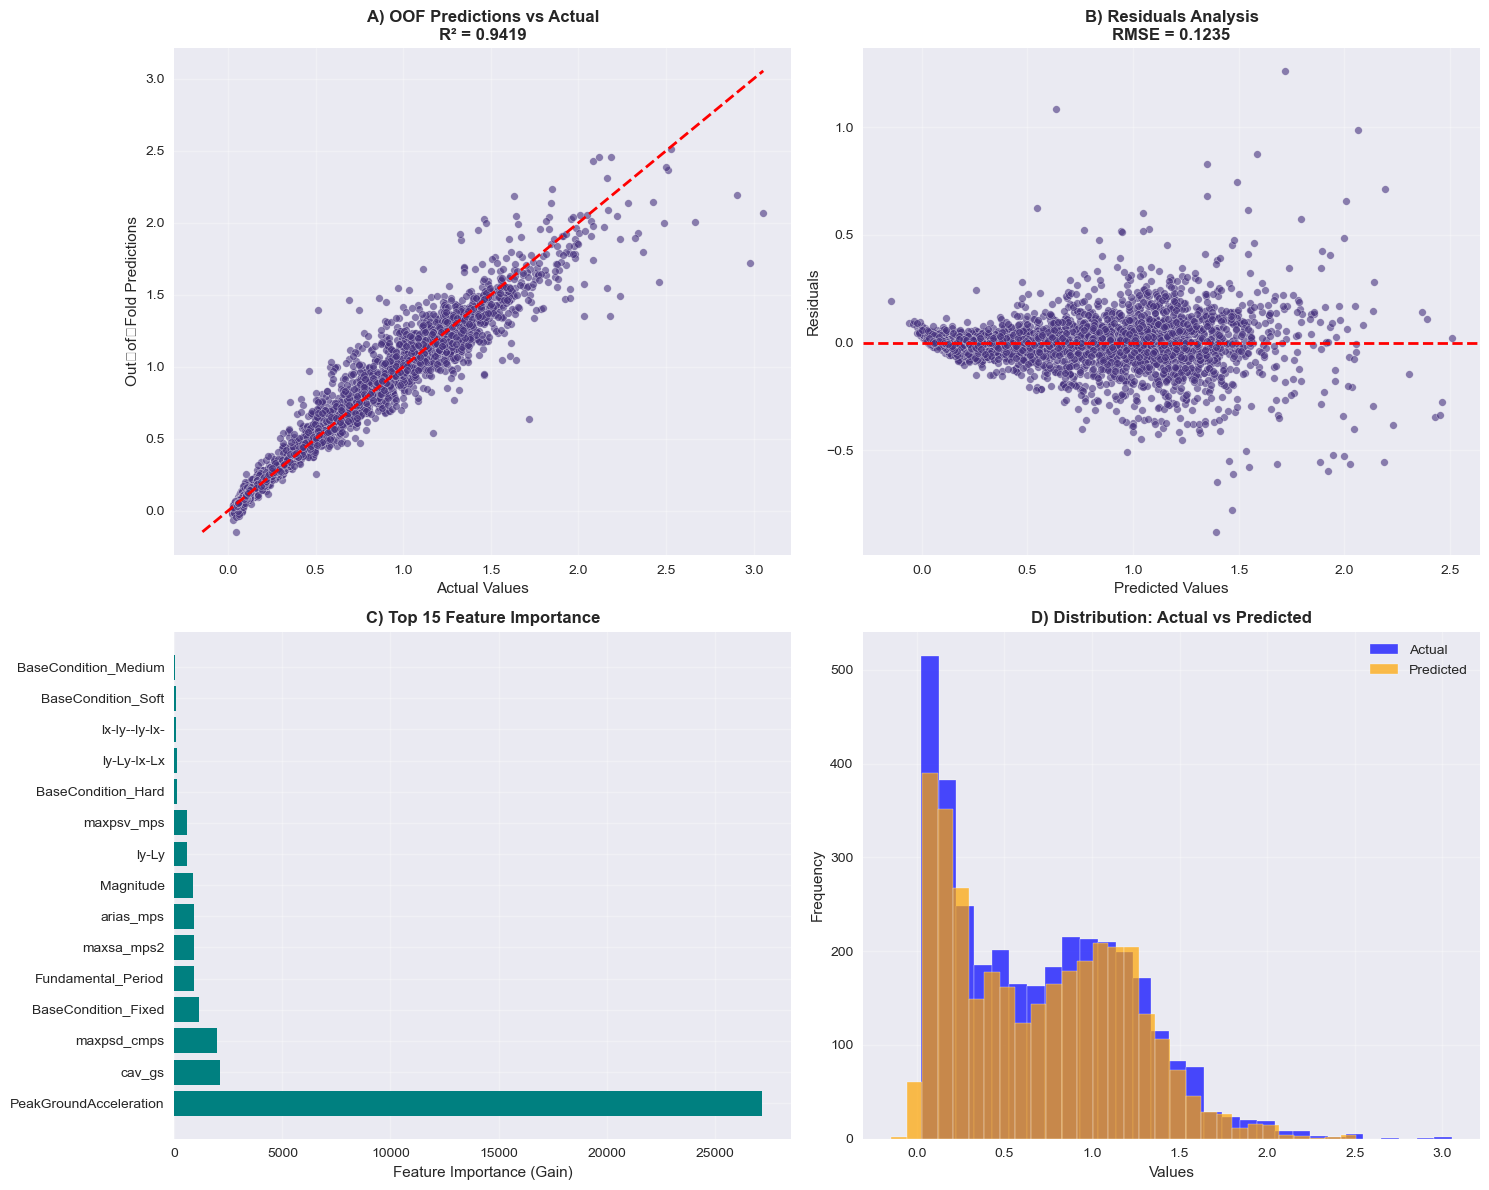


📊 RESEARCH PAPER R² (OOF): 0.941896
✅ LightGBM model info saved to: ModelInfo_Set_3_.txt
✅ Full package saved


In [11]:
# Assuming you have X (features) and y (target) as pandas objects
ModelSet = 3
X, y = DatasetCall(ModelSet)

# 1. Define your hyperparameters (can be tuned via grid search)
params = {
    'n_estimators': 15000,
    'learning_rate': 0.01,
    'max_depth': 5,
    'num_leaves': 32,
    'reg_alpha': 0.1,          # L1 regularization
    'reg_lambda': 0.1,         # L2 regularization
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_samples': 20,
    'boosting_type': 'gbdt',
    'objective': 'regression',
    'metric': 'l1',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

# 2. Run the full pipeline (OOF + final model) – returns a model object and a final trained model
model, final_model = run_optimized_lightgbm(params, X, y)

# 3. Extract and save complete model information (using the same X, y)
final_model_info = extract_lightgbm_model_info(final_model, X, y, f'ModelInfo_Set_{ModelSet}_.txt')

# 4. Define additional metadata (these should match your preprocessing steps)
DoNormalize = False          # Set to True if you normalized features
Z_ScoreScaler = None         # If you used a scaler, assign the fitted object here
includeCategoricalData = False  # Set to True if you have categorical features

# 5. Save the model in a compact package
import joblib

model_package = {
    "model": final_model,
    "feature_names": X.columns.tolist(),
    "parameters": params,
    "DoNormalize": DoNormalize,
    "Z_ScoreScaler": Z_ScoreScaler,
    "ModelSet": ModelSet,
    "includeCategoricalData": includeCategoricalData
}

joblib.dump(model_package, f"LightGBM_Set_{ModelSet}.joblib")
print("✅ Full package saved")
